<a href="https://colab.research.google.com/github/smchakma/ResearchWithSkillMoprh/blob/main/Matplotlib_and_Seaborn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
DATA_DIR = '/content/drive/MyDrive/Datasets'

students = pd.read_csv(f'{DATA_DIR}/StudentsPerformance.csv')
gym = pd.read_csv(f'{DATA_DIR}/gym_membership.csv')

print(f'students shape: {students.shape}')
print(f'gym shape: {gym.shape}')

students shape: (1000, 8)
gym shape: (1000, 17)


In [5]:
students.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [6]:
students.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [7]:
students.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


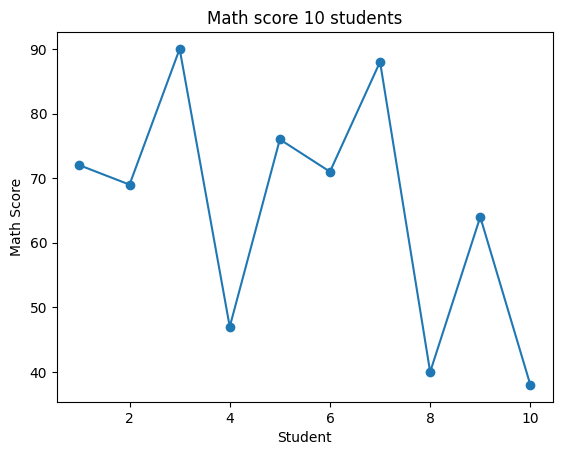

In [8]:
scores = students['math score'].head(10)

fig, ax = plt.subplots()
ax.plot(range(1, 11), scores, marker = 'o')
ax.set(title='Math score 10 students', xlabel='Student', ylabel='Math Score')
plt.savefig("/content/drive/MyDrive/Datasets/Math_score_figure.png", dpi=300, bbox_inches='tight')
plt.show()

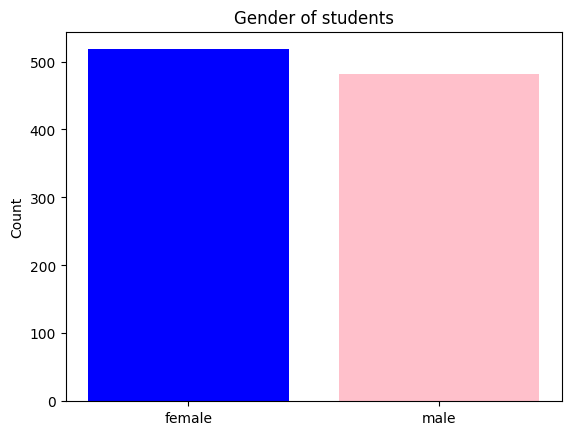

In [9]:
gender_counts = students['gender'].value_counts()

fig, ax = plt.subplots()
ax.bar(gender_counts.index, gender_counts.values, color=['blue', 'pink'])
ax.set(title='Gender of students', ylabel='Count')
plt.savefig("/content/drive/MyDrive/Datasets/Gender_figure.png", dpi=300, bbox_inches='tight')
plt.show()

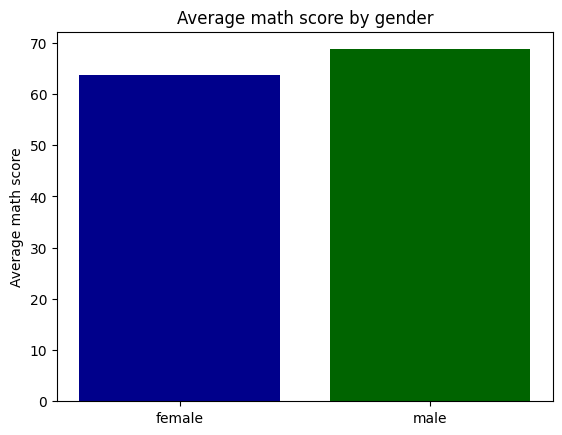

In [22]:
av_math = students.groupby('gender')['math score'].mean()

fig, ax = plt.subplots()
ax.bar(av_math.index, av_math.values, color=['darkblue', 'darkgreen'])
ax.set(title='Average math score by gender', ylabel='Average math score')
plt.savefig("/content/drive/MyDrive/Datasets/Average_math_score_by_gender_figure.png", dpi=600, bbox_inches='tight')
plt.show()

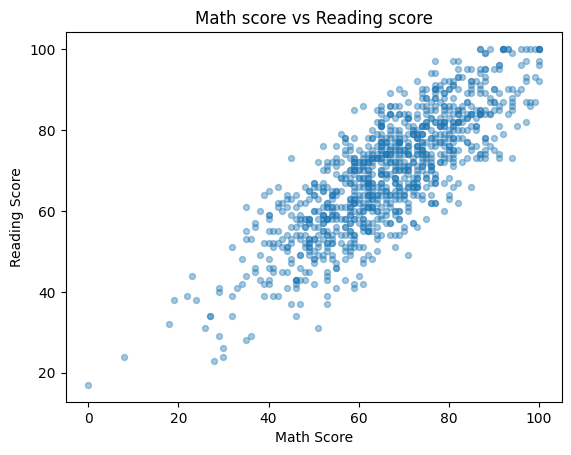

In [12]:
fig, ax = plt.subplots()
ax.scatter(students['math score'], students['reading score'], alpha = 0.4, s = 18)
ax.set(title='Math score vs Reading score', xlabel='Math Score', ylabel='Reading Score')
plt.savefig("/content/drive/MyDrive/Datasets/Math_score_vs_Reading_score_figure.png", dpi=600, bbox_inches='tight')
plt.show()

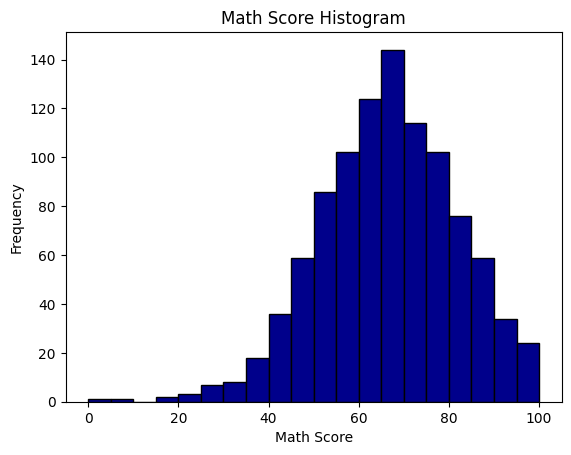

In [15]:
##Histograam

fig, ax = plt.subplots()
ax.hist(students['math score'], bins = 20, color = 'darkblue', edgecolor = 'black')
ax.set(title='Math Score Histogram', xlabel='Math Score', ylabel='Frequency')
plt.savefig("/content/drive/MyDrive/Datasets/Math_Score_Histogram_figure.png", dpi=600, bbox_inches='tight')
plt.show()

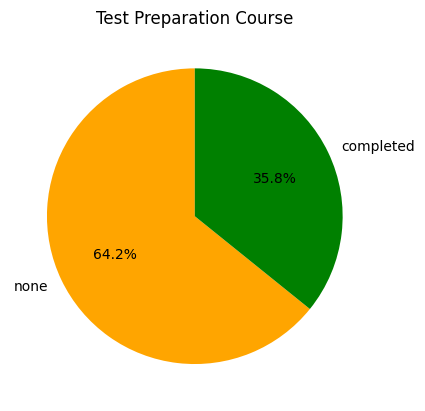

In [18]:
##Pie_Chart

prep = students['test preparation course'].value_counts()

fig, ax = plt.subplots()
ax.pie(prep, labels = prep.index, autopct= '%1.1f%%', colors = ['orange', 'green'], startangle = 90)
ax.set(title='Test Preparation Course')
plt.savefig("/content/drive/MyDrive/Datasets/Test_Preparation_Course_figure.png", dpi=600, bbox_inches='tight')
plt.show()

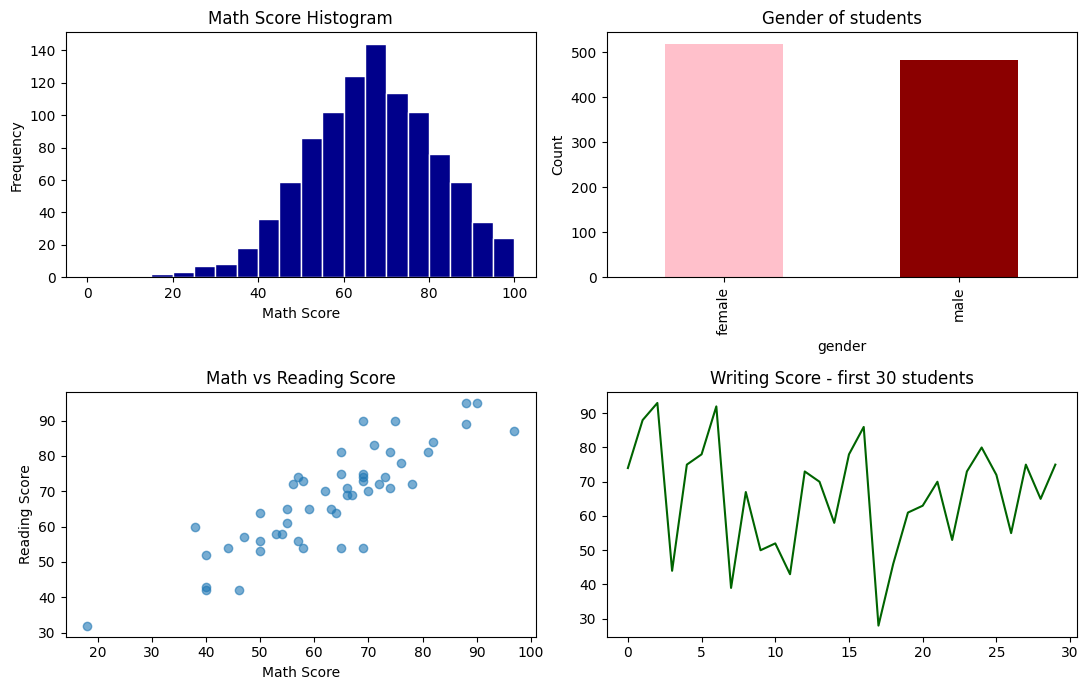

In [22]:
##sub plots ___multiple view in one figure

fig, axes = plt.subplots(2, 2, figsize = (11, 7))
axes[0, 0].hist(students['math score'], bins = 20, color = 'darkblue', edgecolor = 'white')
axes[0, 0].set(title='Math Score Histogram', xlabel='Math Score', ylabel='Frequency')

# Fixed: changed axes(0, 1) to axes[0, 1]
students['gender'].value_counts().plot(kind = 'bar', ax = axes[0, 1], color = ['pink', 'darkred'] )
axes[0, 1].set(title='Gender of students', ylabel='Count')

axes[1, 0].scatter(students['math score'].head(50), students['reading score'].head(50), alpha = 0.6)
axes[1,0].set(title='Math vs Reading Score', xlabel='Math Score', ylabel='Reading Score')

axes[1,1].plot(students['writing score'].head(30), color = 'darkgreen')
axes[1,1].set(title='Writing Score - first 30 students')

plt.savefig("/content/drive/MyDrive/Datasets/Multiple_view_figure.png", dpi=600, bbox_inches='tight')
plt.tight_layout()
plt.show()

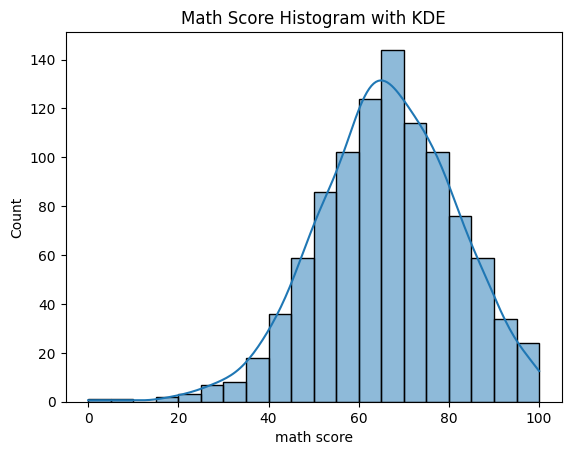

In [24]:
### Seaborn plot
##Histogram

fig, ax = plt.subplots()
sns.histplot(students['math score'], bins=20, kde = True, ax=ax)
ax.set(title='Math Score Histogram with KDE')

# Fixed: Corrected path casing from 'mydrive/datasets' to 'MyDrive/Datasets'
plt.savefig("/content/drive/MyDrive/Datasets/Histro_fig.png", dpi = 300, bbox_inches = 'tight')
plt.show()

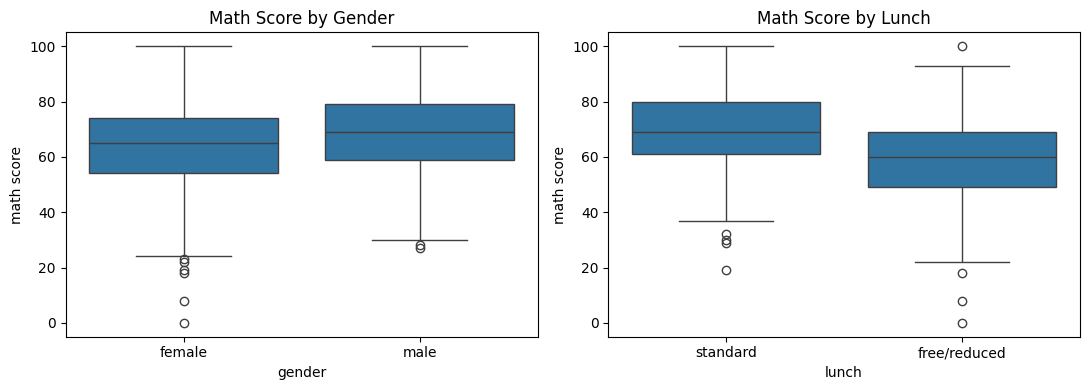

In [27]:
## box plot

fig, ax = plt.subplots(1, 2, figsize = (11, 4))

sns.boxplot(data = students, x = 'gender', y = 'math score', ax = ax[0])
ax[0].set(title='Math Score by Gender')

sns.boxplot(data = students, x = 'lunch', y = 'math score', ax = ax[1])
ax[1].set(title='Math Score by Lunch')


plt.savefig("/content/drive/MyDrive/Datasets/Box_fig.png", dpi = 300, bbox_inches = 'tight')
plt.tight_layout()
plt.show()


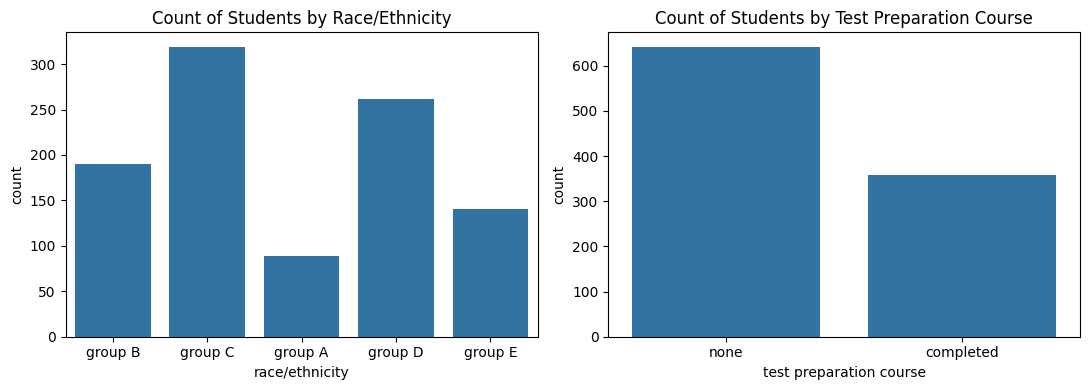

In [30]:
##count plot

fig, ax = plt.subplots(1, 2, figsize = (11, 4))
sns.countplot(data = students, x = 'race/ethnicity', ax = ax[0])
ax[0].set(title='Count of Students by Race/Ethnicity')

sns.countplot(data = students, x = 'test preparation course', ax = ax[1])
ax[1].set(title='Count of Students by Test Preparation Course')

plt.savefig("/content/drive/MyDrive/Datasets/Count_fig.png", dpi = 300, bbox_inches = 'tight')
plt.tight_layout()
plt.show()

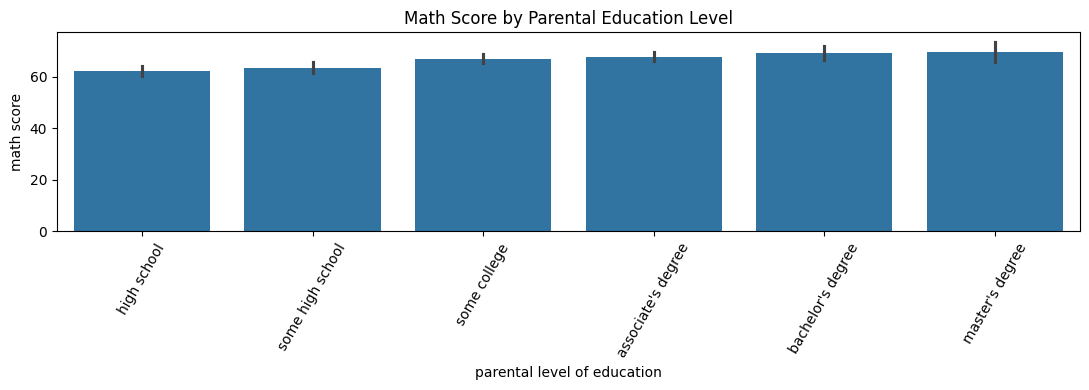

In [33]:
##bar plot

fig, ax = plt.subplots(figsize = (11, 4))
# Fixed: changed 'match score' to 'math score'
others = students.groupby('parental level of education')['math score'].mean().sort_values().index
sns.barplot(data = students, x = 'parental level of education', y = 'math score', order = others, ax = ax)
ax.set_title('Math Score by Parental Education Level')

ax.tick_params(axis = 'x', rotation = 60)
# Fixed: Corrected path casing
plt.savefig("/content/drive/MyDrive/Datasets/barplot_figure_seaborn.png", dpi = 300, bbox_inches='tight')
plt.tight_layout()
plt.show()